 Первая свёртка `3x3, stride 1` вместо `7x7, stride 2`, начальный `maxpool` убран. Без этого картинка 32x32 сжимается до 8x8 ещё до первого residual-блока, и последние слои работают с картой 1x1.
2. Атака должна работать в пространстве `[0, 1]`, иначе ограничение вроде eps = 8/255 теряет смысл

In [1]:
import os, time, tarfile, shutil, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

SEED = 0
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


EPOCHS       = 30      # 30 эпох дают 90%+
BATCH_SIZE   = 128
LR           = 0.1
MOMENTUM     = 0.9
WEIGHT_DECAY = 5e-4
VAL_SIZE     = 5000    #
NUM_WORKERS  = 2

CKPT_PATH = "/kaggle/working/resnet18_cifar10_best.pt" if Path("/kaggle/working").exists() else "resnet18_cifar10_best.pt"

Device: cuda
GPU: Tesla T4


In [2]:
def locate_cifar10():
    work = Path("/kaggle/working/data") if Path("/kaggle/working").exists() else Path("./data")
    work.mkdir(parents=True, exist_ok=True)

    for p in Path("/kaggle/input").rglob("cifar-10-batches-py") if Path("/kaggle/input").exists() else []:
        if p.is_dir():
            link = work / "cifar-10-batches-py" #батчи
            if not link.exists():
                os.symlink(p, link)
            print("Найдены готовые батчи:", p)
            return work, False

    for p in Path("/kaggle/input").rglob("cifar-10-python.tar.gz") if Path("/kaggle/input").exists() else []:
        if not (work / "cifar-10-batches-py").exists():
            print("Распаковываю", p)
            with tarfile.open(p) as tar:
                tar.extractall(work)
        return work, False

    print("Датасет не найден в /kaggle/input, буду скачивать (нужен Internet: On)")
    return work, True


DATA_ROOT, NEED_DOWNLOAD = locate_cifar10()

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
eval_tf = transforms.Compose([transforms.ToTensor()])

full_train = torchvision.datasets.CIFAR10(DATA_ROOT, train=True,  download=NEED_DOWNLOAD, transform=train_tf)
val_source = torchvision.datasets.CIFAR10(DATA_ROOT, train=True,  download=False,         transform=eval_tf)
test_set   = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=NEED_DOWNLOAD, transform=eval_tf)

g = torch.Generator().manual_seed(SEED)
n_train = len(full_train) - VAL_SIZE
train_idx, val_idx = random_split(range(len(full_train)), [n_train, VAL_SIZE], generator=g)

train_set = torch.utils.data.Subset(full_train, list(train_idx))
val_set   = torch.utils.data.Subset(val_source, list(val_idx))

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

CLASSES = ("airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck")
print(f"train {len(train_set)} | val {len(val_set)} | test {len(test_set)}")

x, y = next(iter(train_loader))
print("batch:", x.shape, "диапазон значений:", float(x.min()), "-", float(x.max()))

Датасет не найден в /kaggle/input, буду скачивать (нужен Internet: On)


100%|██████████| 170M/170M [15:47<00:00, 180kB/s] 


train 45000 | val 5000 | test 10000
batch: torch.Size([128, 3, 32, 32]) диапазон значений: 0.0 - 1.0


Отличия CIFAR-версии от `torchvision.models.resnet18`: `conv1` это `3x3, stride 1, padding 1`, и `maxpool` заменён на `Identity`. Размеры карт по стадиям: 32 → 32 → 16 → 8 → 4.

In [3]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)


class Normalize(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, 1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class ResNetCIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, mean=CIFAR10_MEAN, std=CIFAR10_STD):
        super().__init__()
        self.normalize = Normalize(mean, std)
        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False) #тут поменяли чтобы было 3*3
        self.bn1   = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], 1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], 2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], 2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], 2)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_planes, planes, s))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.normalize(x)
        out = F.relu(self.bn1(self.conv1(out)))
        out = self.layer1(out); out = self.layer2(out)
        out = self.layer3(out); out = self.layer4(out)
        out = F.adaptive_avg_pool2d(out, 1).flatten(1)
        return self.linear(out)


def ResNet18():
    return ResNetCIFAR(BasicBlock, [2, 2, 2, 2])


model = ResNet18().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params/1e6:.2f}M")

# проверка размеров карт
with torch.no_grad():
    t = torch.zeros(1, 3, 32, 32, device=DEVICE)
    t = F.relu(model.bn1(model.conv1(model.normalize(t))))
    for name in ["layer1", "layer2", "layer3", "layer4"]:
        t = getattr(model, name)(t)
        print(f"{name}: {tuple(t.shape[1:])}")

Параметров: 11.17M
layer1: (64, 32, 32)
layer2: (128, 16, 16)
layer3: (256, 8, 8)
layer4: (512, 4, 4)


In [4]:
criterion = nn.CrossEntropyLoss()  #обучение
optimizer = torch.optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM,
                            weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader))
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


@torch.no_grad()
def evaluate(net, loader):
    net.eval()
    correct = total = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = net(x)
            loss_sum += criterion(out, y).item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total, loss_sum / total


def train_one_epoch(net, loader):
    net.train()
    correct = total = 0
    loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            out = net(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        loss_sum += loss.item() * y.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total, loss_sum / total


history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
best_val = 0.0
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    tr_acc, tr_loss = train_one_epoch(model, train_loader)
    va_acc, va_loss = evaluate(model, val_loader)

    history["train_acc"].append(tr_acc); history["val_acc"].append(va_acc)
    history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)

    star = ""
    if va_acc > best_val:
        best_val = va_acc
        torch.save({"epoch": epoch, "state_dict": model.state_dict(),
                    "val_acc": va_acc}, CKPT_PATH)
        star = "  <-- best" #лучший чекпоинт

    print(f"epoch {epoch:3d}/{EPOCHS} | lr {scheduler.get_last_lr()[0]:.4f} | "
          f"train {tr_acc*100:.2f}% | val {va_acc*100:.2f}%{star}")

print(f"\nОбучение заняло {(time.time()-t0)/60:.1f} мин. Лучшая val accuracy: {best_val*100:.2f}%")

/tmp/ipykernel_59/2035715812.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_59/2035715812.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
/tmp/ipykernel_59/2035715812.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


epoch   1/30 | lr 0.0069 | train 48.58% | val 58.26%  <-- best
epoch   2/30 | lr 0.0152 | train 66.85% | val 67.92%  <-- best
epoch   3/30 | lr 0.0280 | train 73.77% | val 71.68%  <-- best
epoch   4/30 | lr 0.0437 | train 77.85% | val 70.50%
epoch   5/30 | lr 0.0604 | train 80.41% | val 77.06%  <-- best
epoch   6/30 | lr 0.0760 | train 82.30% | val 75.74%
epoch   7/30 | lr 0.0888 | train 83.82% | val 77.66%  <-- best
epoch   8/30 | lr 0.0971 | train 85.11% | val 78.98%  <-- best
epoch   9/30 | lr 0.1000 | train 85.95% | val 80.62%  <-- best
epoch  10/30 | lr 0.0994 | train 86.86% | val 84.32%  <-- best
epoch  11/30 | lr 0.0978 | train 87.66% | val 84.16%
epoch  12/30 | lr 0.0950 | train 88.25% | val 85.78%  <-- best
epoch  13/30 | lr 0.0913 | train 88.55% | val 84.16%
epoch  14/30 | lr 0.0866 | train 89.19% | val 85.54%
epoch  15/30 | lr 0.0812 | train 89.32% | val 85.96%  <-- best
epoch  16/30 | lr 0.0750 | train 90.05% | val 84.88%
epoch  17/30 | lr 0.0682 | train 90.33% | val 82.88%

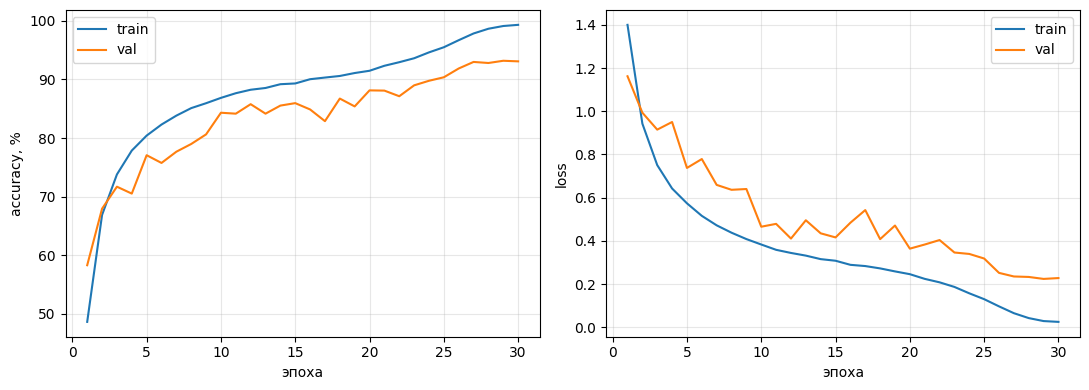

In [5]:
import matplotlib.pyplot as plt #кривая обучния

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ep = range(1, len(history["train_acc"]) + 1)

ax[0].plot(ep, [a*100 for a in history["train_acc"]], label="train")
ax[0].plot(ep, [a*100 for a in history["val_acc"]], label="val")
ax[0].set_xlabel("эпоха"); ax[0].set_ylabel("accuracy, %"); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(ep, history["train_loss"], label="train")
ax[1].plot(ep, history["val_loss"], label="val")
ax[1].set_xlabel("эпоха"); ax[1].set_ylabel("loss"); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [6]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE) #оценка на тесте
model.load_state_dict(ckpt["state_dict"])
print(f"Загружен чекпоинт с эпохи {ckpt['epoch']} (val {ckpt['val_acc']*100:.2f}%)")

test_acc, test_loss = evaluate(model, test_loader)
print(f"\nЧистая точность на тесте: {test_acc*100:.2f}%")

model.eval()
correct = torch.zeros(10); total = torch.zeros(10)
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        pred = model(x).argmax(1)
        for c in range(10):
            m = (y == c)
            correct[c] += (pred[m] == c).sum().item()
            total[c] += m.sum().item()

for c in range(10):
    print(f"{CLASSES[c]:>12}: {correct[c]/total[c]*100:5.1f}%")

Загружен чекпоинт с эпохи 29 (val 93.20%)


/tmp/ipykernel_59/2035715812.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):



Чистая точность на тесте: 93.30%
    airplane:  95.0%
  automobile:  97.0%
        bird:  90.2%
         cat:  85.5%
        deer:  96.3%
         dog:  88.8%
        frog:  95.8%
       horse:  95.0%
        ship:  95.4%
       truck:  94.0%


In [7]:
def fgsm(net, x, y, eps):  #
    x = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(net(x), y)
    grad = torch.autograd.grad(loss, x)[0]
    x_adv = x + eps * grad.sign()
    return x_adv.clamp(0, 1).detach()   # работаем в [0,1], нормализация внутри модели


model.eval()
for eps_num in [1, 2, 4, 8]:
    eps = eps_num / 255
    correct = total = 0
    for x, y in test_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        x_adv = fgsm(model, x, y, eps)
        with torch.no_grad():
            correct += (model(x_adv).argmax(1) == y).sum().item()
        total += y.size(0)
        if total >= 2000:      
            break
    print(f"eps = {eps_num}/255 -> accuracy {correct/total*100:5.2f}%")

eps = 1/255 -> accuracy 52.54%
eps = 2/255 -> accuracy 29.00%
eps = 4/255 -> accuracy 15.28%
eps = 8/255 -> accuracy  8.89%
